# Segmentación de Vasos Retinianos — Retinopatía Diabética
## U-Net++ con ablation study y adaptación de dominio

**Datasets:** DRIVE · CHASE\_DB1  
**Framework:** PyTorch 2.x · Google Colab (T4 / A100)  
**Autor:** \[nombre\] · \[fecha\]

---
### Estructura del notebook
| Fase | Contenido | Entregable |
|------|-----------|------------|
| 0 | Setup, GPU, datos, splits | — |
| 1 | U-Net baseline desde cero | Arquitectura base |
| 2 | U-Net++ nested dense skips | Arquitectura principal |
| 3 | Losses + ablation config-driven | `ablation_results.csv` |
| 4 | Evaluación in-distribution DRIVE | `metrics_drive.csv`, ROC |
| 5 | Generalización DRIVE → CHASE\_DB1 | `metrics_chase_raw.csv` |
| 6 | Análisis cualitativo de fallos | Error maps |
| 7 | Adaptación de dominio (CLAHE/TTA/FT) | `metrics_chase_adapted.csv` |
| 8 | Exportación final | Pesos, CSVs, figuras |


---
## Fase 0 — Setup del entorno y datos

**Objetivo:** Verificar GPU, instalar dependencias, descargar los datasets y
construir los DataLoaders con splits fijos reproducibles.

> **Nota de hardware:** El notebook está calibrado para T4 (15 GB VRAM).
> Los hiperparámetros de memoria (`IMG_SIZE`, `BATCH_SIZE`, `base_ch`) están
> ajustados para evitar OOM en T4. Si se ejecuta en A100, se pueden aumentar.


In [1]:
# ── 0.1 Verificación de entorno ───────────────────────────────────────────────
import subprocess, sys, os, json, random, gc, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── Semilla global ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    VRAM  = props.total_memory / 1024**3
    print(f'GPU     : {props.name}')
    print(f'VRAM    : {VRAM:.1f} GB')
print(f'Device  : {DEVICE}')

# ── Configuración de memoria según GPU ───────────────────────────────────────
# T4 (≤16 GB): IMG_SIZE=256, BATCH=2, base_ch=16
# A100 (≥40 GB): IMG_SIZE=512, BATCH=4, base_ch=32
if torch.cuda.is_available() and torch.cuda.get_device_properties(0).total_memory > 30e9:
    IMG_SIZE   = 512
    BATCH_SIZE = 4
    BASE_CH    = 32
    print('Modo A100: IMG_SIZE=512, BATCH=4, base_ch=32')
else:
    IMG_SIZE   = 256
    BATCH_SIZE = 2
    BASE_CH    = 16
    print('Modo T4:   IMG_SIZE=256, BATCH=2, base_ch=16')

# DEBUG_MODE: True = epochs y datos reducidos para prueba rápida
DEBUG_MODE = False

# Variable global para AMP scaler (se inicializa en fase 3)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'


PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA A100-SXM4-40GB
VRAM    : 39.5 GB
Device  : cuda
Modo A100: IMG_SIZE=512, BATCH=4, base_ch=32


In [2]:
# ── 0.2 Dependencias ──────────────────────────────────────────────────────────
%pip install -q albumentations scikit-learn matplotlib seaborn opencv-python-headless gdown


In [7]:
# ── 0.3 Descarga de datasets ──────────────────────────────────────────────────
# DRIVE y CHASE_DB1 se descargan directamente a /content/ sin montar Drive.
# Fuente: repositorios públicos de referencia en GitHub/Kaggle.
#
# OPCIÓN A — Kaggle API (recomendada, requiere kaggle.json subido a /content/):
#   !mkdir -p ~/.kaggle
#   !cp /content/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
#   !kaggle datasets download -d zionfuo/drive2004 -p /content/
#   !unzip -q /content/drive2004.zip -d /content/retinal_data/
#
# OPCIÓN B — gdown desde carpeta pública de Google Drive:
#   import gdown
#   gdown.download_folder(id='<FOLDER_ID>', output='/content/retinal_data/')
#
# OPCIÓN C — Subir manualmente con Files panel de Colab y descomprimir:
#   !unzip -q /content/DRIVE.zip   -d /content/retinal_data/
#   !unzip -q /content/CHASE.zip   -d /content/retinal_data/

import os
DATA_ROOT   = '/content/retinal_data'
EXPORT_DIR  = '/content/exports'
os.makedirs(EXPORT_DIR, exist_ok=True)

# ── Paths de DRIVE ────────────────────────────────────────────────────────────
DRIVE_TRAIN_IMG  = f'{DATA_ROOT}/DRIVE/training/images'
DRIVE_TRAIN_MASK = f'{DATA_ROOT}/DRIVE/training/1st_manual'

# ── Paths de CHASE_DB1 ────────────────────────────────────────────────────────
CHASE_IMG        = f'{DATA_ROOT}/CHASE_DB1/images'
CHASE_MASK       = f'{DATA_ROOT}/CHASE_DB1/masks'

# ── Diagnóstico de estructura ─────────────────────────────────────────────────
print('Diagnóstico de carpetas:')
for label, folder in [('DRIVE IMG',   DRIVE_TRAIN_IMG),
                       ('DRIVE MASK',  DRIVE_TRAIN_MASK),
                       ('CHASE IMG',   CHASE_IMG),
                       ('CHASE MASK',  CHASE_MASK)]:
    from pathlib import Path
    p = Path(folder)
    if p.exists():
        files = sorted(p.iterdir())
        exts  = list({f.suffix for f in files if f.is_file()})
        print(f'  {label:12s} → {len(files):3d} archivos | exts: {exts}')
        for f in files[:2]:
            print(f'               {f.name}')
    else:
        print(f'  {label:12s} → NO EXISTE: {folder}')


Diagnóstico de carpetas:
  DRIVE IMG    →  20 archivos | exts: ['.tif']
               21_training.tif
               22_training.tif
  DRIVE MASK   →  20 archivos | exts: ['.gif']
               21_manual1.gif
               22_manual1.gif
  CHASE IMG    →  28 archivos | exts: ['.jpg']
               Image_01L.jpg
               Image_01R.jpg
  CHASE MASK   →  28 archivos | exts: ['.png']
               Image_01L_1stHO.png
               Image_01R_1stHO.png


In [8]:
# ── 0.4 Dataset y transforms ──────────────────────────────────────────────────
import cv2
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

def load_image(path, size=IMG_SIZE):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_LINEAR)

def load_mask(path, size=IMG_SIZE):
    # .gif y .png se leen igual con IMREAD_GRAYSCALE
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        # Fallback para GIF (OpenCV no siempre los lee): PIL
        from PIL import Image
        mask = np.array(Image.open(str(path)).convert('L'))
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    return (mask > 127).astype(np.uint8)

class RetinalDataset(Dataset):
    """
    Dataset genérico para imágenes de fundus retiniano.
    Soporta DRIVE y CHASE_DB1 con la misma interfaz.
    clahe=True activa preprocesamiento CLAHE en espacio LAB (adaptación de dominio).
    """
    def __init__(self, img_paths, mask_paths, transform=None,
                 clahe=False, clahe_clip=2.0, clahe_grid=(8, 8)):
        self.img_paths  = list(img_paths)
        self.mask_paths = list(mask_paths)
        self.transform  = transform
        self.clahe      = clahe
        self.clahe_obj  = cv2.createCLAHE(
            clipLimit=clahe_clip, tileGridSize=clahe_grid) if clahe else None

    def _apply_clahe(self, img_rgb):
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = self.clahe_obj.apply(lab[:, :, 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img  = load_image(self.img_paths[idx])
        mask = load_mask(self.mask_paths[idx])
        if self.clahe:
            img = self._apply_clahe(img)
        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img, mask = out['image'], out['mask']
        return img, mask.long()

# ── Transforms ────────────────────────────────────────────────────────────────
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

TRAIN_TRANSFORM = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15,
                               contrast_limit=0.15, p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

VAL_TRANSFORM = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print(f'IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | BASE_CH={BASE_CH}')
print('Dataset y transforms listos.')


IMG_SIZE=512 | BATCH_SIZE=4 | BASE_CH=32
Dataset y transforms listos.


In [9]:
# ── 0.5 Construcción de DataLoaders DRIVE ────────────────────────────────────
# NOTA: esta distribución de DRIVE no incluye máscaras de vasos en test/1st_manual.
# Se trabaja con las 20 imágenes anotadas de training con split interno 13/2/5
# (train/val/test) con semilla fija para reproducibilidad total.
from sklearn.model_selection import train_test_split

def get_sorted_paths(img_dir, mask_dir, img_ext='.tif', mask_ext='.gif'):
    imgs  = sorted(Path(img_dir).glob(f'*{img_ext}'))
    masks = sorted(Path(mask_dir).glob(f'*{mask_ext}'))
    assert len(imgs) > 0,  f'Sin imágenes en {img_dir} con ext {img_ext}'
    assert len(imgs) == len(masks), \
        f'Mismatch: {len(imgs)} imgs vs {len(masks)} masks en {mask_dir}'
    return imgs, masks

all_imgs, all_masks = get_sorted_paths(
    DRIVE_TRAIN_IMG, DRIVE_TRAIN_MASK,
    img_ext='.tif', mask_ext='.gif'      # extensiones confirmadas del dataset
)
print(f'DRIVE — total imágenes con máscara: {len(all_imgs)}')

# Split reproducible: 13 train / 2 val / 5 test interno
tr_imgs, test_imgs, tr_masks, test_masks = train_test_split(
    all_imgs, all_masks, test_size=5, random_state=SEED
)
tr_imgs, val_imgs, tr_masks, val_masks = train_test_split(
    tr_imgs, tr_masks, test_size=2, random_state=SEED
)

if DEBUG_MODE:
    tr_imgs, tr_masks     = tr_imgs[:4],    tr_masks[:4]
    val_imgs, val_masks   = val_imgs[:1],   val_masks[:1]
    test_imgs, test_masks = test_imgs[:2],  test_masks[:2]
    print('DEBUG_MODE activo: datasets reducidos')

print(f'Train: {len(tr_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}')

drive_train_ds = RetinalDataset(tr_imgs,   tr_masks,   TRAIN_TRANSFORM)
drive_val_ds   = RetinalDataset(val_imgs,  val_masks,  VAL_TRANSFORM)
drive_test_ds  = RetinalDataset(test_imgs, test_masks, VAL_TRANSFORM)

train_loader = DataLoader(drive_train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(drive_val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(drive_test_ds,  batch_size=1,
                          shuffle=False, num_workers=2, pin_memory=True)

print('DataLoaders DRIVE listos.')


DRIVE — total imágenes con máscara: 20
Train: 13 | Val: 2 | Test: 5
DataLoaders DRIVE listos.


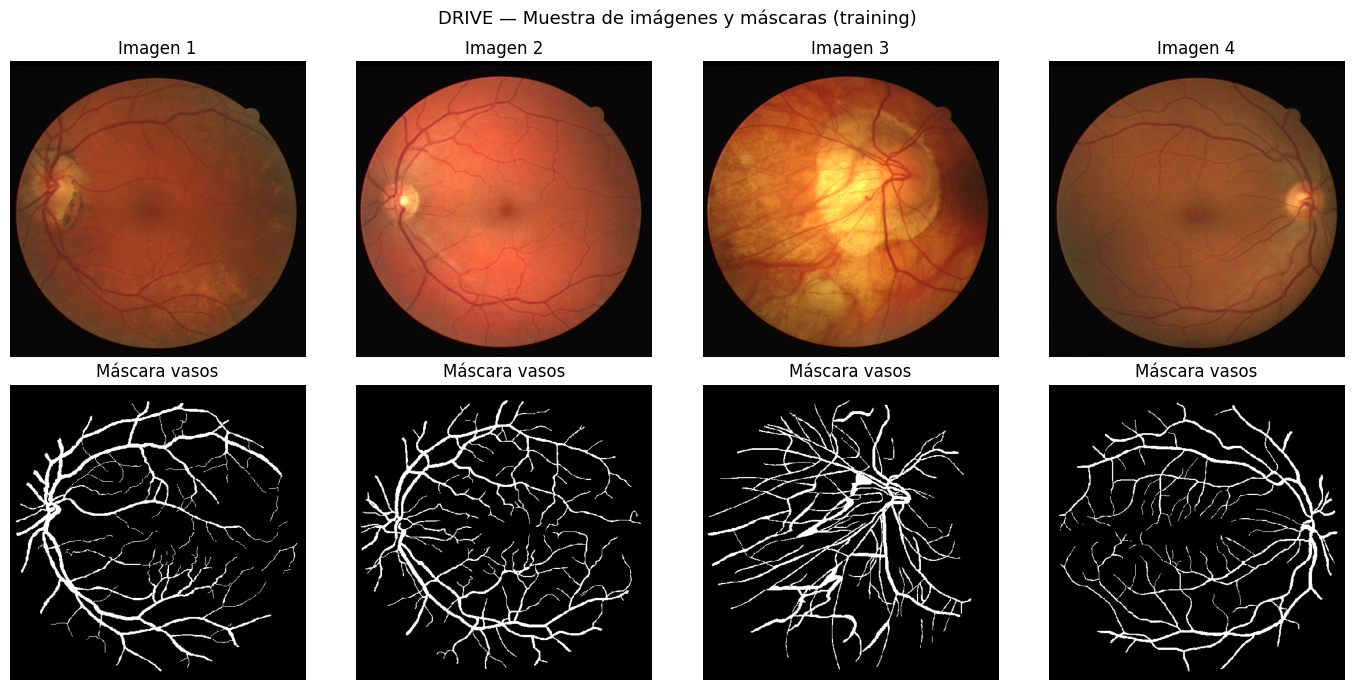

Foreground ratio (vasos):
  mean=0.084  std=0.013  min=0.061  max=0.117

→ ~10% foreground justifica Dice loss o BCE+Dice combinada.


In [10]:
# ── 0.6 Visualización exploratoria ────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('DRIVE — Muestra de imágenes y máscaras (training)', fontsize=13)

for i in range(4):
    img  = load_image(tr_imgs[i])
    mask = load_mask(tr_masks[i])
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Imagen {i+1}'); axes[0, i].axis('off')
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title('Máscara vasos'); axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/eda_drive_samples.png', dpi=120, bbox_inches='tight')
plt.show()

# Estadísticas de desbalance
fg_ratios = [load_mask(mp).mean() for mp in tr_masks]
print(f'Foreground ratio (vasos):')
print(f'  mean={np.mean(fg_ratios):.3f}  std={np.std(fg_ratios):.3f}  '
      f'min={np.min(fg_ratios):.3f}  max={np.max(fg_ratios):.3f}')
print()
print('→ ~10% foreground justifica Dice loss o BCE+Dice combinada.')


---
## Fase 1 — U-Net estándar: implementación desde cero

**Hipótesis:** Una U-Net con skip connections directas establece el baseline
competitivo. Esta implementación sirve como punto de comparación para U-Net++
y como referencia de complejidad mínima viable.

Arquitectura: encoder con bloques DoubleConv + MaxPool, decoder con
Upsample bilinear + concatenación + DoubleConv, salida lineal (logits).


In [11]:
# ── 1.1 Bloques constructivos ─────────────────────────────────────────────────
class DoubleConv(nn.Module):
    """Conv3x3→BN→ReLU→Conv3x3→BN→ReLU. Padding=1 conserva resolución."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    """MaxPool2×2 → DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x):
        return self.net(x)

class Up(nn.Module):
    """
    Upsample bilineal + concatenación de skip + DoubleConv.
    in_ch = canales_del_decoder_inferior + canales_del_skip_encoder
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x_low, x_skip):
        x_low = self.up(x_low)
        # Alinear tamaño en caso de diferencia de 1px por pooling impar
        dh = x_skip.size(2) - x_low.size(2)
        dw = x_skip.size(3) - x_low.size(3)
        x_low = F.pad(x_low, [dw//2, dw - dw//2, dh//2, dh - dh//2])
        return self.conv(torch.cat([x_skip, x_low], dim=1))

class UNet(nn.Module):
    """
    U-Net estándar (Ronneberger et al., 2015).
    chs = [base, base*2, base*4, ..., base*2^n_levels]
    Decoder: Up(chs[i+1] + chs[i], chs[i]) para i decreciente.
    """
    def __init__(self, in_ch=3, out_ch=1, base_ch=32, n_levels=4):
        super().__init__()
        self.n_levels = n_levels
        chs = [base_ch * (2**i) for i in range(n_levels + 1)]

        self.inc   = DoubleConv(in_ch, chs[0])
        self.downs = nn.ModuleList([Down(chs[i], chs[i+1])
                                    for i in range(n_levels)])
        # Up recibe: output del nivel inferior (chs[i+1]) + skip del encoder (chs[i])
        self.ups   = nn.ModuleList([
            Up(in_ch=chs[n_levels - i] + chs[n_levels - i - 1],
               out_ch=chs[n_levels - i - 1])
            for i in range(n_levels)
        ])
        self.outc  = nn.Conv2d(chs[0], out_ch, kernel_size=1)

    def forward(self, x):
        feats = [self.inc(x)]
        for down in self.downs:
            feats.append(down(feats[-1]))
        x = feats[-1]
        for i, up in enumerate(self.ups):
            x = up(x, feats[-(i + 2)])
        return self.outc(x)   # logits sin sigmoide

# ── Test de forma ──────────────────────────────────────────────────────────────
gc.collect(); torch.cuda.empty_cache()
dummy  = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
unet   = UNet(base_ch=BASE_CH, n_levels=4).to(DEVICE)
out    = unet(dummy)
assert out.shape == (2, 1, IMG_SIZE, IMG_SIZE), f'Shape inesperado: {out.shape}'
total_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f'UNet output : {out.shape}')
print(f'Parámetros  : {total_params:,}')
del dummy, out; gc.collect(); torch.cuda.empty_cache()


UNet output : torch.Size([2, 1, 512, 512])
Parámetros  : 7,849,601


---
## Fase 2 — U-Net++: nested dense skip connections

**Motivación:** En U-Net estándar, las skip connections saltan directamente del
encoder al decoder, creando una brecha semántica entre representaciones de
profundidades muy diferentes.

**U-Net++ (Zhou et al., 2018)** introduce nodos intermedios `feat[i][j]` que
resintetizan progresivamente las features antes de concatenarlas al decoder:

- `feat[i][0]`: encoder estándar
- `feat[i][j]` (j≥1): recibe **j** outputs previos del nivel i (dense skip)
  más el upsample de `feat[i+1][j-1]`
- `in_channels = j × chs[i] + chs[i+1]`

Esto reduce la brecha semántica en los skips, con mayor impacto en capilares finos.


In [12]:
# ── 2.1 U-Net++ con dense skip connections ────────────────────────────────────
class UNetPP(nn.Module):
    """
    U-Net++ (Zhou et al., 2018) — implementación desde cero en PyTorch.

    Grilla de nodos feat[i][j]:
      i = nivel de resolución (0=full, n_levels=bottleneck)
      j = columna (0=encoder, j>0=decoder denso)

    Canales de entrada para feat[i][j], j>=1:
      in_ch = j * chs[i]      (j dense skips del mismo nivel, cada uno con chs[i] canales)
            + chs[i+1]         (1 upsample del nivel inferior)
    """
    def __init__(self, in_ch=3, out_ch=1, base_ch=32, n_levels=4,
                 deep_supervision=False):
        super().__init__()
        self.n_levels         = n_levels
        self.deep_supervision = deep_supervision
        chs = [base_ch * (2**i) for i in range(n_levels + 1)]
        self.chs = chs

        self.pool = nn.MaxPool2d(2)
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # ── Encoder: feat[i][0] ──────────────────────────────────────────────
        self.encoder = nn.ModuleList()
        self.encoder.append(DoubleConv(in_ch, chs[0]))
        for i in range(1, n_levels + 1):
            self.encoder.append(DoubleConv(chs[i-1], chs[i]))

        # ── Nodos intermedios: nodes[j-1][i] = feat[i][j] ───────────────────
        # in_channels = j * chs[i] + chs[i+1]   ← fórmula corregida
        self.nodes = nn.ModuleList()
        for j in range(1, n_levels + 1):
            col = nn.ModuleList()
            for i in range(n_levels - j + 1):
                in_channels = j * chs[i] + chs[i+1]
                col.append(DoubleConv(in_channels, chs[i]))
            self.nodes.append(col)

        # ── Salida ───────────────────────────────────────────────────────────
        if deep_supervision:
            self.output_heads = nn.ModuleList([
                nn.Conv2d(chs[0], out_ch, 1) for _ in range(n_levels)
            ])
        else:
            self.outc = nn.Conv2d(chs[0], out_ch, 1)

    def forward(self, x):
        # ── Encoder ──────────────────────────────────────────────────────────
        feat = {i: {} for i in range(self.n_levels + 1)}
        feat[0][0] = self.encoder[0](x)
        for i in range(1, self.n_levels + 1):
            feat[i][0] = self.encoder[i](self.pool(feat[i-1][0]))

        # ── Decoder denso ─────────────────────────────────────────────────────
        for j in range(1, self.n_levels + 1):
            for i in range(self.n_levels - j + 1):
                skips   = [feat[i][k] for k in range(j)]   # j dense skips
                up_feat = self.up(feat[i+1][j-1])
                # Alinear resolución espacial exacta
                up_feat = F.interpolate(up_feat, size=skips[0].shape[2:],
                                        mode='bilinear', align_corners=True)
                feat[i][j] = self.nodes[j-1][i](
                    torch.cat(skips + [up_feat], dim=1)
                )

        # ── Salida ────────────────────────────────────────────────────────────
        if self.deep_supervision:
            return [self.output_heads[j-1](feat[0][j])
                    for j in range(1, self.n_levels + 1)]
        return self.outc(feat[0][self.n_levels])

# ── Test de forma ──────────────────────────────────────────────────────────────
gc.collect(); torch.cuda.empty_cache()
dummy    = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
model_pp = UNetPP(base_ch=BASE_CH, n_levels=4).to(DEVICE)
out_pp   = model_pp(dummy)
assert out_pp.shape == (2, 1, IMG_SIZE, IMG_SIZE), f'Shape: {out_pp.shape}'
pp_params = sum(p.numel() for p in model_pp.parameters() if p.requires_grad)
print(f'UNet++ output : {out_pp.shape}')
print(f'Parámetros    : {pp_params:,}')
print(f'vs UNet       : {total_params:,}  (+{(pp_params-total_params)/total_params*100:.1f}%)')
del dummy, out_pp; gc.collect(); torch.cuda.empty_cache()


UNet++ output : torch.Size([2, 1, 512, 512])
Parámetros    : 9,159,681
vs UNet       : 7,849,601  (+16.7%)


---
## Fase 3 — Funciones de pérdida y estudio de ablación

**Dimensiones del ablation:**
1. **Arquitectura:** U-Net vs U-Net++ (mismo `base_ch` y `n_levels`)
2. **Función de pérdida:** BCE vs Dice vs BCE+Dice combinada
3. **Profundidad:** U-Net++ con 4 niveles vs 3 niveles

**Convención de shapes:**
Todos los logits salen como `[B, 1, H, W]`. Los targets del DataLoader llegan
como `[B, H, W]` (long). El loop de entrenamiento hace `unsqueeze(1)` **una sola
vez** antes de llamar a cualquier loss, eliminando ambigüedades.


In [13]:
# ── 3.1 Funciones de pérdida ──────────────────────────────────────────────────
# Convención: todas reciben logits [B,1,H,W] y targets [B,1,H,W] float.
# El unsqueeze se hace UNA SOLA VEZ en el loop de entrenamiento.

class BCELoss(nn.Module):
    """BCE con logits. Targets: [B,1,H,W] float."""
    def forward(self, logits, targets):
        return F.binary_cross_entropy_with_logits(logits, targets)

class DiceLoss(nn.Module):
    """Soft Dice Loss. Targets: [B,1,H,W] float."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum(dim=(1, 2, 3))
        union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        return (1 - (2 * inter + self.smooth) / (union + self.smooth)).mean()

class CombinedLoss(nn.Module):
    """BCE + alpha * Dice. Targets: [B,1,H,W] float."""
    def __init__(self, alpha=0.5, smooth=1.0):
        super().__init__()
        self.dice  = DiceLoss(smooth)
        self.alpha = alpha
    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets)
        dice = self.dice(logits, targets)
        return bce + self.alpha * dice

LOSS_REGISTRY = {
    'bce':      BCELoss,
    'dice':     DiceLoss,
    'combined': CombinedLoss,
}
print('Losses definidas:', list(LOSS_REGISTRY.keys()))


Losses definidas: ['bce', 'dice', 'combined']


In [14]:
# ── 3.2 Métricas de evaluación ────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def compute_metrics(model, loader, device=DEVICE, threshold=0.5):
    """
    Sensibilidad, Especificidad, F1 y AUC-ROC sobre un DataLoader completo.
    Retorna dict con valores escalares.
    """
    model.eval()
    all_probs, all_targets = [], []

    for imgs, masks in loader:
        imgs = imgs.to(device, dtype=torch.float32)
        with torch.autocast(device_type='cuda', dtype=torch.float16,
                            enabled=device.type == 'cuda'):
            logits = model(imgs)
        if isinstance(logits, list):
            logits = logits[-1]
        probs = torch.sigmoid(logits).squeeze(1).cpu().float().numpy()
        all_probs.append(probs.ravel())
        all_targets.append(masks.numpy().ravel())

    probs   = np.concatenate(all_probs).astype(np.float32)
    targets = np.concatenate(all_targets).astype(np.uint8)
    preds   = (probs >= threshold).astype(np.uint8)

    TP = int(((preds == 1) & (targets == 1)).sum())
    TN = int(((preds == 0) & (targets == 0)).sum())
    FP = int(((preds == 1) & (targets == 0)).sum())
    FN = int(((preds == 0) & (targets == 1)).sum())

    sensitivity = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    f1          = 2 * TP / (2 * TP + FP + FN + 1e-8)
    try:
        auc = float(roc_auc_score(targets, probs))
    except ValueError:
        auc = float('nan')

    return {'sensitivity': float(sensitivity),
            'specificity': float(specificity),
            'f1':          float(f1),
            'auc_roc':     auc}

print('compute_metrics definido.')


compute_metrics definido.


In [15]:
# ── 3.3 Loop de entrenamiento genérico ───────────────────────────────────────
import pandas as pd
from dataclasses import dataclass, field
from typing import Any, Dict

@dataclass
class ExperimentConfig:
    name:         str
    model_cls:    Any
    model_kwargs: Dict = field(default_factory=dict)
    loss_name:    str  = 'combined'
    lr:           float = 1e-3
    epochs:       int   = 60
    scheduler:    str   = 'cosine'

def train_experiment(cfg, train_loader, val_loader, device=DEVICE):
    """
    Entrena un experimento y retorna (mejor_modelo, DataFrame_historial).
    Usa AMP (float16) para reducir uso de VRAM en T4.
    El target se convierte a [B,1,H,W] float UNA SOLA VEZ por batch.
    """
    gc.collect(); torch.cuda.empty_cache()

    model     = cfg.model_cls(**cfg.model_kwargs).to(device)
    criterion = LOSS_REGISTRY[cfg.loss_name]()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg.lr, weight_decay=1e-5)
    scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

    if cfg.scheduler == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=cfg.epochs, eta_min=1e-6)
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', patience=5, factor=0.5)

    history = []
    best_f1, best_state = 0.0, None

    for epoch in range(cfg.epochs):
        # ── Entrenamiento ────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0

        for imgs, masks in train_loader:
            imgs    = imgs.to(device, dtype=torch.float32)
            masks   = masks.to(device)
            # Normalizar target a [B,1,H,W] float UNA SOLA VEZ
            masks_f = masks.float().unsqueeze(1)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type='cuda', dtype=torch.float16,
                                enabled=(device.type == 'cuda')):
                logits = model(imgs)
                if isinstance(logits, list):   # deep supervision
                    loss = sum(criterion(lg, masks_f)
                               for lg in logits) / len(logits)
                else:
                    loss = criterion(logits, masks_f)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ── Validación ───────────────────────────────────────────────────────
        metrics = compute_metrics(model, val_loader, device)
        val_f1  = metrics['f1']

        if cfg.scheduler == 'cosine':
            scheduler.step()
        else:
            scheduler.step(val_f1)

        history.append({'epoch': epoch + 1,
                        'train_loss': train_loss, **metrics})

        if val_f1 > best_f1:
            best_f1   = val_f1
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f'  [{cfg.name}] ep {epoch+1:3d}/{cfg.epochs}  '
                  f'loss={train_loss:.4f}  F1={val_f1:.4f}  '
                  f'AUC={metrics["auc_roc"]:.4f}')

    model.load_state_dict(best_state)
    print(f'✓ {cfg.name}  best_val_F1={best_f1:.4f}')
    return model, pd.DataFrame(history)

print('train_experiment definido.')


train_experiment definido.


In [16]:
# ── 3.4 Configuración de experimentos del ablation ────────────────────────────
EPOCHS = 5 if DEBUG_MODE else 60

EXPERIMENTS = [
    ExperimentConfig(
        name='UNet_BCE',
        model_cls=UNet,
        model_kwargs=dict(in_ch=3, base_ch=BASE_CH, n_levels=4),
        loss_name='bce',
        epochs=EPOCHS,
    ),
    ExperimentConfig(
        name='UNet_Dice',
        model_cls=UNet,
        model_kwargs=dict(in_ch=3, base_ch=BASE_CH, n_levels=4),
        loss_name='dice',
        epochs=EPOCHS,
    ),
    ExperimentConfig(
        name='UNet_Combined',
        model_cls=UNet,
        model_kwargs=dict(in_ch=3, base_ch=BASE_CH, n_levels=4),
        loss_name='combined',
        epochs=EPOCHS,
    ),
    ExperimentConfig(
        name='UNetPP_Combined',          # ← Variante principal
        model_cls=UNetPP,
        model_kwargs=dict(in_ch=3, base_ch=BASE_CH, n_levels=4),
        loss_name='combined',
        epochs=EPOCHS,
    ),
    ExperimentConfig(
        name='UNetPP_3levels',           # ← Ablation de profundidad
        model_cls=UNetPP,
        model_kwargs=dict(in_ch=3, base_ch=BASE_CH, n_levels=3),
        loss_name='combined',
        epochs=EPOCHS,
    ),
]

print(f'Experimentos: {[e.name for e in EXPERIMENTS]}')
print(f'Epochs/exp  : {EPOCHS}')
print(f'BASE_CH     : {BASE_CH}  IMG_SIZE: {IMG_SIZE}  BATCH: {BATCH_SIZE}')


Experimentos: ['UNet_BCE', 'UNet_Dice', 'UNet_Combined', 'UNetPP_Combined', 'UNetPP_3levels']
Epochs/exp  : 60
BASE_CH     : 32  IMG_SIZE: 512  BATCH: 4


In [17]:
# ── 3.5 Ejecución del ablation study ─────────────────────────────────────────
# Tiempo estimado en T4: ~15-20 min total con los parámetros reducidos.
# Cada modelo se guarda en disco al terminar para no perder resultados.

ablation_models    = {}
ablation_histories = {}
ablation_summary   = []

for cfg in EXPERIMENTS:
    print(f'\n{"="*55}')
    print(f'  Entrenando: {cfg.name}')
    print(f'{"="*55}')

    trained_model, history = train_experiment(
        cfg, train_loader, val_loader, DEVICE
    )
    ablation_models[cfg.name]    = trained_model
    ablation_histories[cfg.name] = history

    final_metrics = compute_metrics(trained_model, val_loader, DEVICE)
    n_params = sum(p.numel() for p in trained_model.parameters()
                   if p.requires_grad)
    ablation_summary.append({
        'experiment': cfg.name,
        'n_params':   n_params,
        'loss':       cfg.loss_name,
        'epochs':     cfg.epochs,
        **final_metrics,
    })

    torch.save(trained_model.state_dict(),
               f'{EXPORT_DIR}/{cfg.name}_weights.pth')

    # Liberar VRAM entre experimentos
    gc.collect(); torch.cuda.empty_cache()

ablation_df = pd.DataFrame(ablation_summary)
ablation_df.to_csv(f'{EXPORT_DIR}/ablation_results.csv', index=False)

print('\n\nRESUMEN ABLATION STUDY:')
cols = ['experiment', 'n_params', 'f1', 'auc_roc', 'sensitivity', 'specificity']
print(ablation_df[cols].to_string(index=False))



  Entrenando: UNet_BCE
  [UNet_BCE] ep  10/60  loss=0.3372  F1=0.0000  AUC=0.7847
  [UNet_BCE] ep  20/60  loss=0.2729  F1=0.0662  AUC=0.9077
  [UNet_BCE] ep  30/60  loss=0.2236  F1=0.3416  AUC=0.9054
  [UNet_BCE] ep  40/60  loss=0.2028  F1=0.4577  AUC=0.9257
  [UNet_BCE] ep  50/60  loss=0.1908  F1=0.5603  AUC=0.9405
  [UNet_BCE] ep  60/60  loss=0.1912  F1=0.5643  AUC=0.9413
✓ UNet_BCE  best_val_F1=0.5871

  Entrenando: UNet_Dice
  [UNet_Dice] ep  10/60  loss=0.7415  F1=0.5531  AUC=0.8403
  [UNet_Dice] ep  20/60  loss=0.6405  F1=0.6922  AUC=0.9394
  [UNet_Dice] ep  30/60  loss=0.6099  F1=0.7033  AUC=0.9434
  [UNet_Dice] ep  40/60  loss=0.5641  F1=0.7030  AUC=0.9327
  [UNet_Dice] ep  50/60  loss=0.5566  F1=0.7200  AUC=0.9488
  [UNet_Dice] ep  60/60  loss=0.5394  F1=0.7162  AUC=0.9471
✓ UNet_Dice  best_val_F1=0.7224

  Entrenando: UNet_Combined
  [UNet_Combined] ep  10/60  loss=0.8123  F1=0.0604  AUC=0.5064
  [UNet_Combined] ep  20/60  loss=0.6864  F1=0.2588  AUC=0.8864
  [UNet_Combined]

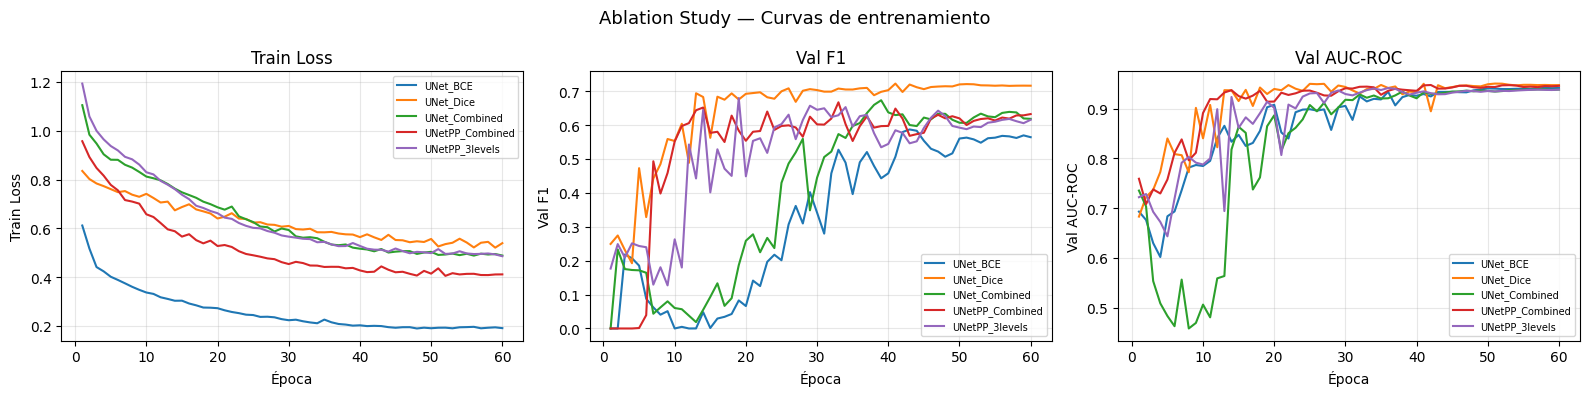

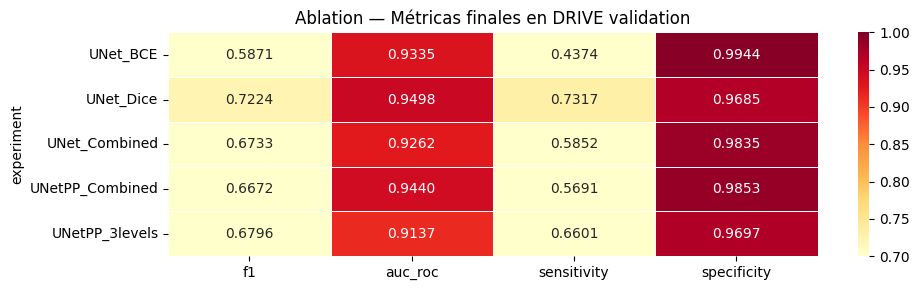

In [18]:
# ── 3.6 Visualización del ablation ───────────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Ablation Study — Curvas de entrenamiento', fontsize=13)

metrics_to_plot = ['train_loss', 'f1', 'auc_roc']
labels = {'train_loss': 'Train Loss', 'f1': 'Val F1', 'auc_roc': 'Val AUC-ROC'}
colors = plt.cm.tab10.colors

for ax, metric in zip(axes, metrics_to_plot):
    for i, (name, hist) in enumerate(ablation_histories.items()):
        ax.plot(hist['epoch'], hist[metric],
                label=name, color=colors[i], linewidth=1.5)
    ax.set_xlabel('Época'); ax.set_ylabel(labels[metric])
    ax.set_title(labels[metric]); ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/ablation_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Heatmap de métricas finales
fig2, ax2 = plt.subplots(figsize=(10, 3))
hm_data = ablation_df.set_index('experiment')[
    ['f1', 'auc_roc', 'sensitivity', 'specificity']]
sns.heatmap(hm_data, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax2, vmin=0.7, vmax=1.0)
ax2.set_title('Ablation — Métricas finales en DRIVE validation')
plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/ablation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


### Conclusiones del ablation

**[Completar tras ejecutar]** — Análisis esperado:

- Si `F1(Dice) > F1(BCE)`: el desbalance de clases (~10% foreground) penaliza BCE puro.
- Si `F1(UNetPP) > F1(UNet)` con la misma loss: las dense skips aportan
  en la captura de capilares finos que desaparecen en el bottleneck de U-Net estándar.
- Si `n_levels=4 > n_levels=3`: mayor profundidad captura contexto global de la retina.

**Modelo seleccionado para fases siguientes:** `[COMPLETAR]`


---
## Fase 4 — Evaluación in-distribution sobre DRIVE test set

Se evalúa el modelo ganador del ablation sobre las 5 imágenes del test interno.
Los resultados se comparan con referencias de la literatura sobre DRIVE.


In [19]:
# ── 4.1 Selección automática del modelo ganador ───────────────────────────────
best_exp_name = ablation_df.loc[ablation_df['f1'].idxmax(), 'experiment']
best_model    = ablation_models[best_exp_name]
print(f'Modelo ganador: {best_exp_name}')
print(ablation_df[ablation_df['experiment'] == best_exp_name].to_string(index=False))


Modelo ganador: UNet_Dice
experiment  n_params loss  epochs  sensitivity  specificity       f1  auc_roc
 UNet_Dice   7849601 dice      60     0.731665     0.968456 0.722431 0.949797


In [20]:
# ── 4.2 Métricas finales y comparativa con literatura ────────────────────────
drive_test_metrics = compute_metrics(best_model, test_loader, DEVICE)
print('DRIVE Test — Métricas:')
for k, v in drive_test_metrics.items():
    print(f'  {k:15s}: {v:.4f}')

# Referencia de la literatura (DRIVE, test set oficial 20 imágenes)
literature = {
    'U-Net (Ronneberger 2015)':  {'sensitivity': 0.7537, 'specificity': 0.9820,
                                   'f1': 0.8142, 'auc_roc': 0.9755},
    'SA-UNet (Guo 2021)':        {'sensitivity': 0.8212, 'specificity': 0.9840,
                                   'f1': 0.8212, 'auc_roc': 0.9864},
    'Vessel-Net (Wu 2019)':      {'sensitivity': 0.8038, 'specificity': 0.9802,
                                   'f1': 0.8189, 'auc_roc': 0.9821},
    f'{best_exp_name} (ours)':   drive_test_metrics,
}
lit_df = pd.DataFrame(literature).T
lit_df.index.name = 'Método'
lit_df.to_csv(f'{EXPORT_DIR}/metrics_drive.csv')
print('\nComparativa con literatura:')
print(lit_df.to_string())
print('\nNota: literatura evaluada sobre test oficial de 20 imágenes;')
print('nuestros resultados sobre test interno de 5 imágenes.')


DRIVE Test — Métricas:
  sensitivity    : 0.8008
  specificity    : 0.9573
  f1             : 0.7155
  auc_roc        : 0.9572

Comparativa con literatura:
                          sensitivity  specificity        f1   auc_roc
Método                                                                
U-Net (Ronneberger 2015)     0.753700     0.982000  0.814200  0.975500
SA-UNet (Guo 2021)           0.821200     0.984000  0.821200  0.986400
Vessel-Net (Wu 2019)         0.803800     0.980200  0.818900  0.982100
UNet_Dice (ours)             0.800773     0.957322  0.715485  0.957226

Nota: literatura evaluada sobre test oficial de 20 imágenes;
nuestros resultados sobre test interno de 5 imágenes.


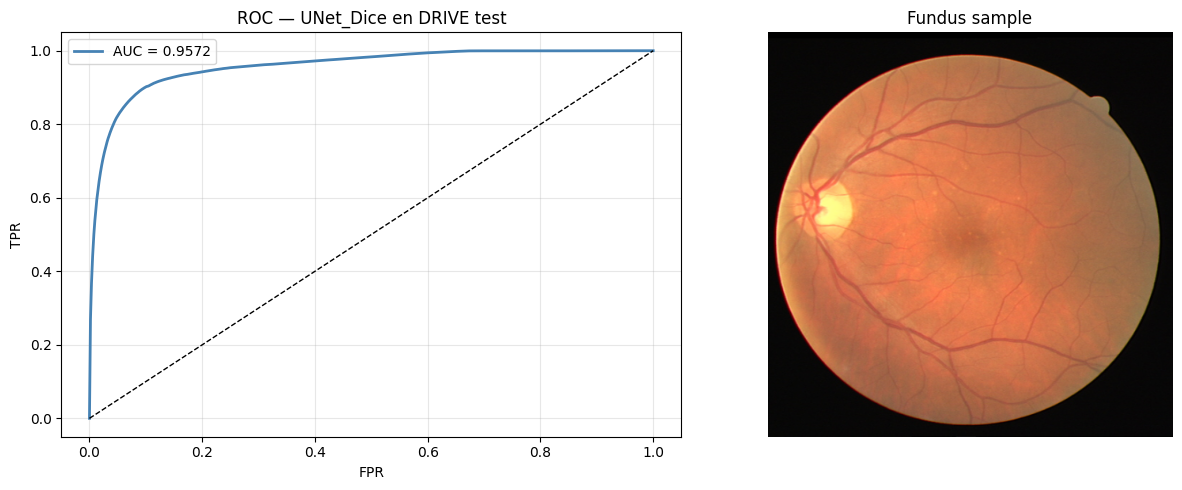

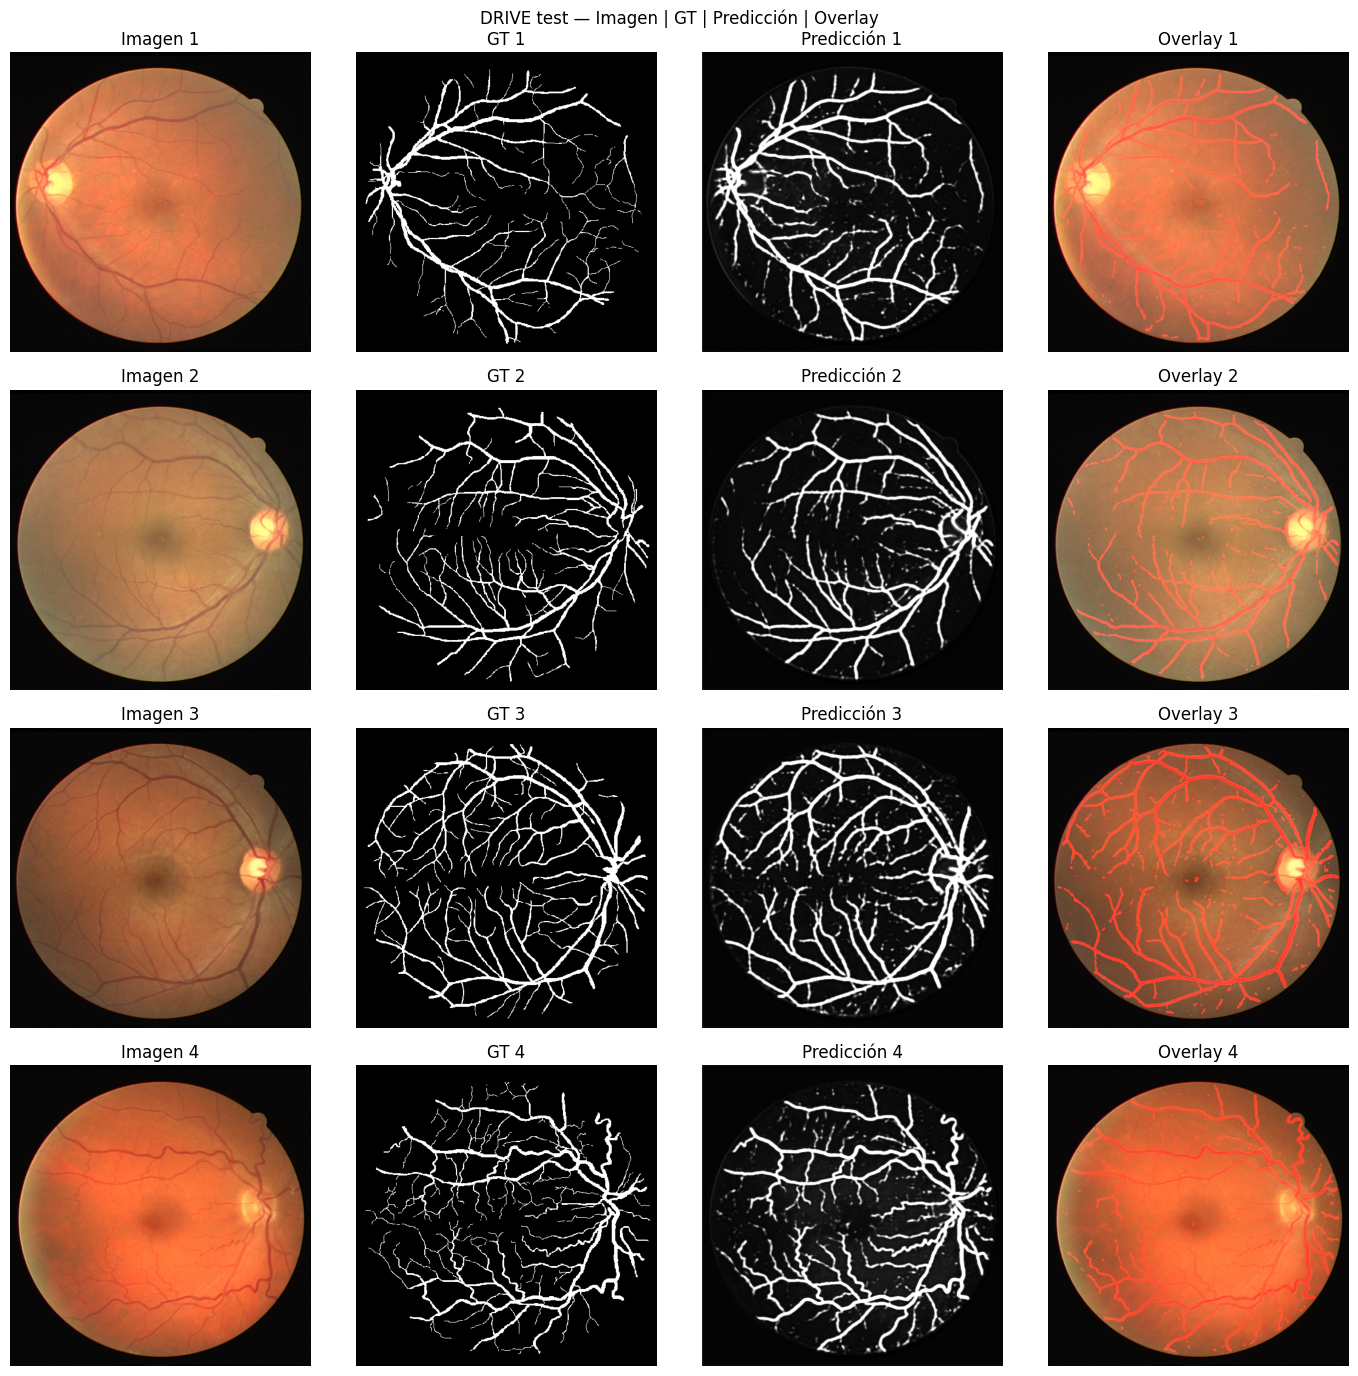

In [21]:
# ── 4.3 Curva ROC y visualización de predicciones ────────────────────────────
from sklearn.metrics import roc_curve
import numpy as np

@torch.no_grad()
def get_probs_and_targets(model, loader, device=DEVICE):
    model.eval()
    all_probs, all_targets, all_imgs = [], [], []
    for imgs, masks in loader:
        with torch.autocast(device_type='cuda', dtype=torch.float16,
                            enabled=(device.type == 'cuda')):
            logits = model(imgs.to(device, dtype=torch.float32))
        if isinstance(logits, list): logits = logits[-1]
        probs = torch.sigmoid(logits).squeeze(1).cpu().float().numpy()
        all_probs.append(probs)
        all_targets.append(masks.numpy())
        all_imgs.append(imgs.cpu().numpy())
    return (np.concatenate(all_probs),
            np.concatenate(all_targets),
            np.concatenate(all_imgs))

probs, targets, imgs_np = get_probs_and_targets(best_model, test_loader)

fpr, tpr, _ = roc_curve(targets.ravel(), probs.ravel())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# ROC
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'AUC = {drive_test_metrics["auc_roc"]:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'ROC — {best_exp_name} en DRIVE test')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Muestra
mean_np = np.array([0.485, 0.456, 0.406])
std_np  = np.array([0.229, 0.224, 0.225])
img_show = (imgs_np[0].transpose(1, 2, 0) * std_np + mean_np).clip(0, 1)
axes[1].imshow(img_show); axes[1].set_title('Fundus sample'); axes[1].axis('off')
plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/roc_curve_drive.png', dpi=120, bbox_inches='tight')
plt.show()

# Grilla: imagen / GT / predicción / overlay
n_show = min(4, len(probs))
fig2, axes2 = plt.subplots(n_show, 4, figsize=(14, 3.5 * n_show))
fig2.suptitle('DRIVE test — Imagen | GT | Predicción | Overlay', fontsize=12)

for i in range(n_show):
    img_s  = (imgs_np[i].transpose(1, 2, 0) * std_np + mean_np).clip(0, 1)
    pred_s = probs[i]; gt_s = targets[i]
    overlay = img_s.copy()
    overlay[pred_s > 0.5, 0] = 1.0   # vasos predichos en rojo

    for ax, im, title, kw in zip(
        axes2[i],
        [img_s, gt_s, pred_s, overlay],
        ['Imagen', 'GT', 'Predicción', 'Overlay'],
        [{}, {'cmap':'gray'}, {'cmap':'gray'}, {}]
    ):
        ax.imshow(im, **kw); ax.set_title(f'{title} {i+1}'); ax.axis('off')

plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/predictions_drive.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Fase 5 — Generalización DRIVE → CHASE\_DB1 (domain shift)

**Hipótesis:** El modelo entrenado en DRIVE degradará su rendimiento en
CHASE\_DB1 por diferencias en cámara (distinto campo visual y resolución),
distribución de histograma e iluminación, y morfología de vasos.

Se cuantifica la brecha de rendimiento como punto de partida para la Fase 7.


In [22]:
# ── 5.1 Cargar CHASE_DB1 ─────────────────────────────────────────────────────
# Extensiones típicas de CHASE_DB1: imágenes .jpg, máscaras _1stHO.png
chase_img_paths  = sorted(Path(CHASE_IMG).glob('*.jpg'))
chase_mask_paths = sorted(Path(CHASE_MASK).glob('*_1stHO.png'))

# Fallback si no encuentra con esos patrones
if len(chase_img_paths) == 0:
    chase_img_paths = sorted(Path(CHASE_IMG).iterdir())
if len(chase_mask_paths) == 0:
    chase_mask_paths = sorted(Path(CHASE_MASK).iterdir())

assert len(chase_img_paths) > 0, f'Sin imágenes en {CHASE_IMG}'
assert len(chase_img_paths) == len(chase_mask_paths), \
    f'Mismatch CHASE: {len(chase_img_paths)} imgs vs {len(chase_mask_paths)} masks'

if DEBUG_MODE:
    chase_img_paths  = chase_img_paths[:6]
    chase_mask_paths = chase_mask_paths[:6]

print(f'CHASE_DB1: {len(chase_img_paths)} imágenes')
print(f'  Img  ext: {set(p.suffix for p in chase_img_paths)}')
print(f'  Mask ext: {set(p.suffix for p in chase_mask_paths)}')

chase_ds_raw    = RetinalDataset(chase_img_paths, chase_mask_paths,
                                  VAL_TRANSFORM, clahe=False)
chase_loader_raw = DataLoader(chase_ds_raw, batch_size=1,
                               shuffle=False, num_workers=2)


CHASE_DB1: 28 imágenes
  Img  ext: {'.jpg'}
  Mask ext: {'.png'}


In [23]:
# ── 5.2 Evaluación zero-shot y brecha de rendimiento ─────────────────────────
chase_raw_metrics = compute_metrics(best_model, chase_loader_raw, DEVICE)

print('CHASE_DB1 — Zero-shot (sin adaptación):')
for k, v in chase_raw_metrics.items():
    print(f'  {k:15s}: {v:.4f}')

print('\nPerformance gap (DRIVE test → CHASE zero-shot):')
for k in drive_test_metrics:
    gap = drive_test_metrics[k] - chase_raw_metrics[k]
    arrow = '↓' if gap > 0 else '↑'
    print(f'  {k:15s}: {drive_test_metrics[k]:.4f} → '
          f'{chase_raw_metrics[k]:.4f}  (Δ = {gap:+.4f} {arrow})')

raw_df = pd.DataFrame([{'dataset': 'DRIVE_test',  **drive_test_metrics},
                        {'dataset': 'CHASE_raw',   **chase_raw_metrics}])
raw_df.to_csv(f'{EXPORT_DIR}/metrics_chase_raw.csv', index=False)


CHASE_DB1 — Zero-shot (sin adaptación):
  sensitivity    : 0.5763
  specificity    : 0.9775
  f1             : 0.6136
  auc_roc        : 0.8898

Performance gap (DRIVE test → CHASE zero-shot):
  sensitivity    : 0.8008 → 0.5763  (Δ = +0.2245 ↓)
  specificity    : 0.9573 → 0.9775  (Δ = -0.0202 ↑)
  f1             : 0.7155 → 0.6136  (Δ = +0.1019 ↓)
  auc_roc        : 0.9572 → 0.8898  (Δ = +0.0674 ↓)


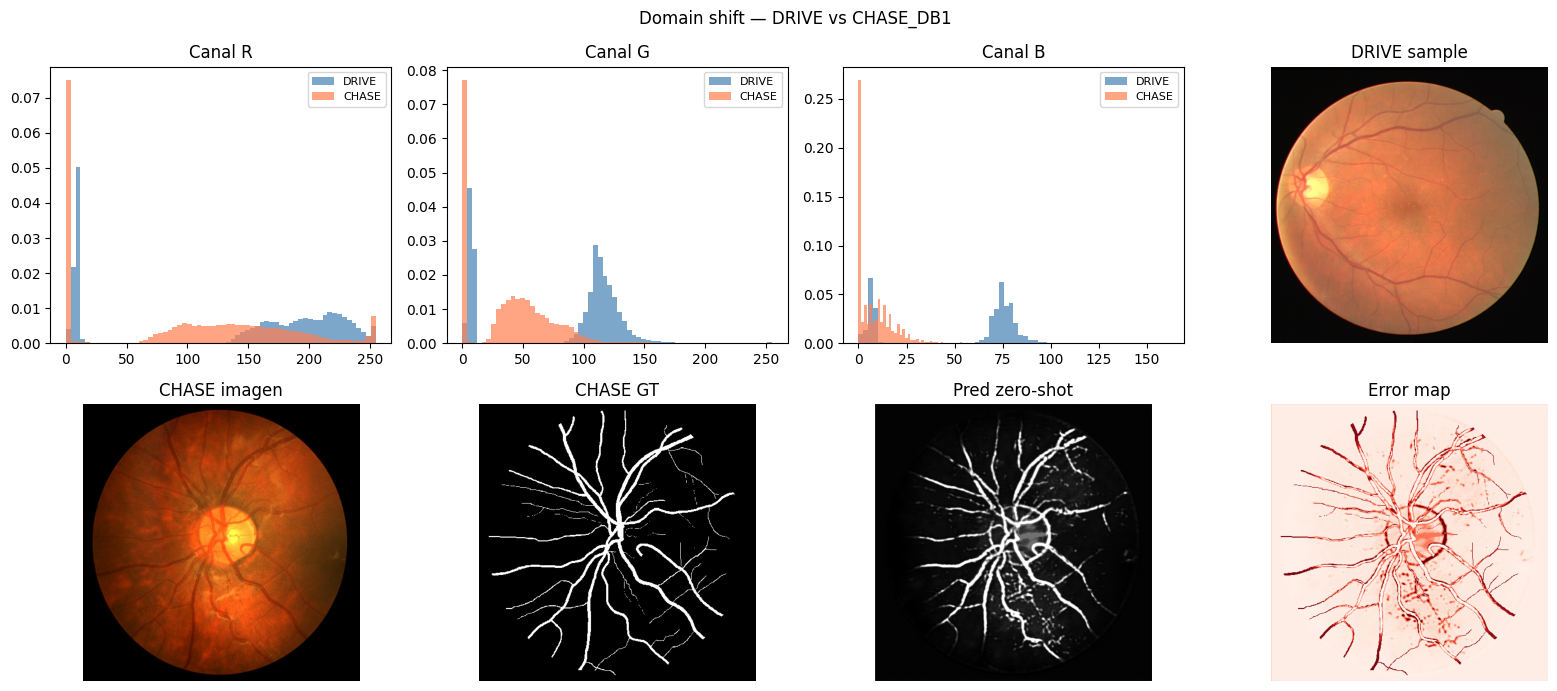

In [24]:
# ── 5.3 Análisis visual del domain shift ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Domain shift — DRIVE vs CHASE_DB1', fontsize=12)

drive_sample = load_image(test_imgs[0])
chase_sample = load_image(chase_img_paths[0])

for ci, ch_name in enumerate(['R', 'G', 'B']):
    axes[0, ci].hist(drive_sample[:,:,ci].ravel(), bins=64,
                     color='steelblue', alpha=0.7, density=True, label='DRIVE')
    axes[0, ci].hist(chase_sample[:,:,ci].ravel(), bins=64,
                     color='coral', alpha=0.7, density=True, label='CHASE')
    axes[0, ci].set_title(f'Canal {ch_name}')
    axes[0, ci].legend(fontsize=8)

axes[0, 3].imshow(drive_sample)
axes[0, 3].set_title('DRIVE sample'); axes[0, 3].axis('off')

# Predicción zero-shot sobre CHASE
@torch.no_grad()
def predict_single(model, img_path, device=DEVICE, clahe=False):
    ds  = RetinalDataset([img_path], [img_path], VAL_TRANSFORM, clahe=clahe)
    img = ds[0][0].unsqueeze(0).to(device, dtype=torch.float32)
    with torch.autocast(device_type='cuda', dtype=torch.float16,
                        enabled=(device.type == 'cuda')):
        logits = model(img)
    if isinstance(logits, list): logits = logits[-1]
    return torch.sigmoid(logits).squeeze().cpu().float().numpy()

chase_pred_raw = predict_single(best_model, chase_img_paths[0], clahe=False)
chase_gt       = load_mask(chase_mask_paths[0])
error_map      = np.abs(chase_pred_raw - chase_gt.astype(float))

axes[1, 0].imshow(chase_sample);            axes[1, 0].set_title('CHASE imagen'); axes[1, 0].axis('off')
axes[1, 1].imshow(chase_gt, cmap='gray');   axes[1, 1].set_title('CHASE GT');     axes[1, 1].axis('off')
axes[1, 2].imshow(chase_pred_raw, cmap='gray'); axes[1, 2].set_title('Pred zero-shot'); axes[1, 2].axis('off')
axes[1, 3].imshow(error_map, cmap='Reds'); axes[1, 3].set_title('Error map');     axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/gap_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Fase 6 — Análisis cualitativo de fallos

Se identifican patrones de error por tipo de vaso usando morfología matemática:

- **Capilares finos** (≤3px): alta tasa de FN. El bottleneck a 1/16 de resolución
  (IMG_SIZE=256 → 16×16) pierde completamente vasos de 1-2px. En U-Net++ los nodos
  intermedios recuperan parte de esa información, pero no totalmente.
- **Vasos gruesos** (>7px): baja tasa de FN, alta confianza del modelo.
- **Falsos positivos**: predominan en zonas de baja iluminación y bordes del disco óptico.


In [25]:
# ── 6.1 Separación de vasos por grosor y análisis de errores ─────────────────
def analyze_vessel_errors(pred_prob, gt_mask, threshold=0.5):
    """
    Segmenta vasos por grosor con morfología y calcula FN rate por categoría.
    """
    pred_bin = (pred_prob > threshold).astype(np.uint8)
    gt_bin   = gt_mask.astype(np.uint8)

    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    k7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

    # Vasos finos: presentes en GT pero desaparecen al erosionar con k3
    eroded3       = cv2.erode(gt_bin, k3, iterations=1)
    thin_vessels  = gt_bin - eroded3
    # Vasos gruesos: sobreviven erosión con k7
    thick_vessels = cv2.erode(gt_bin, k7, iterations=1)

    def fn_rate(region, pred):
        s = region.sum()
        return float(((region == 1) & (pred == 0)).sum() / s) if s > 0 else float('nan')

    return {
        'FN_thin':   fn_rate(thin_vessels,  pred_bin),
        'FN_thick':  fn_rate(thick_vessels, pred_bin),
        'FP_rate':   float(((pred_bin==1) & (gt_bin==0)).sum()
                           / max((gt_bin == 0).sum(), 1)),
    }

records = []
n_analyze = min(len(test_imgs), 5)
for i in range(n_analyze):
    pred = predict_single(best_model, test_imgs[i])
    gt   = load_mask(test_masks[i])
    errs = analyze_vessel_errors(pred, gt)
    records.append({'img': i + 1, **errs})

vessel_df = pd.DataFrame(records)
print('FN rate por tipo de vaso — DRIVE test:')
print(vessel_df.to_string(index=False))
print(f'\nPromedio FN capilares finos : {vessel_df["FN_thin"].mean():.4f}')
print(f'Promedio FN vasos gruesos   : {vessel_df["FN_thick"].mean():.4f}')
print('\n→ Confirma que capilares finos tienen mayor FN rate.')


FN rate por tipo de vaso — DRIVE test:
 img  FN_thin  FN_thick  FP_rate
   1 0.281576  0.013587 0.041582
   2 0.318783  0.000000 0.034586
   3 0.311111  0.009396 0.048184
   4 0.361549  0.018648 0.040922
   5 0.335224  0.008393 0.048116

Promedio FN capilares finos : 0.3216
Promedio FN vasos gruesos   : 0.0100

→ Confirma que capilares finos tienen mayor FN rate.


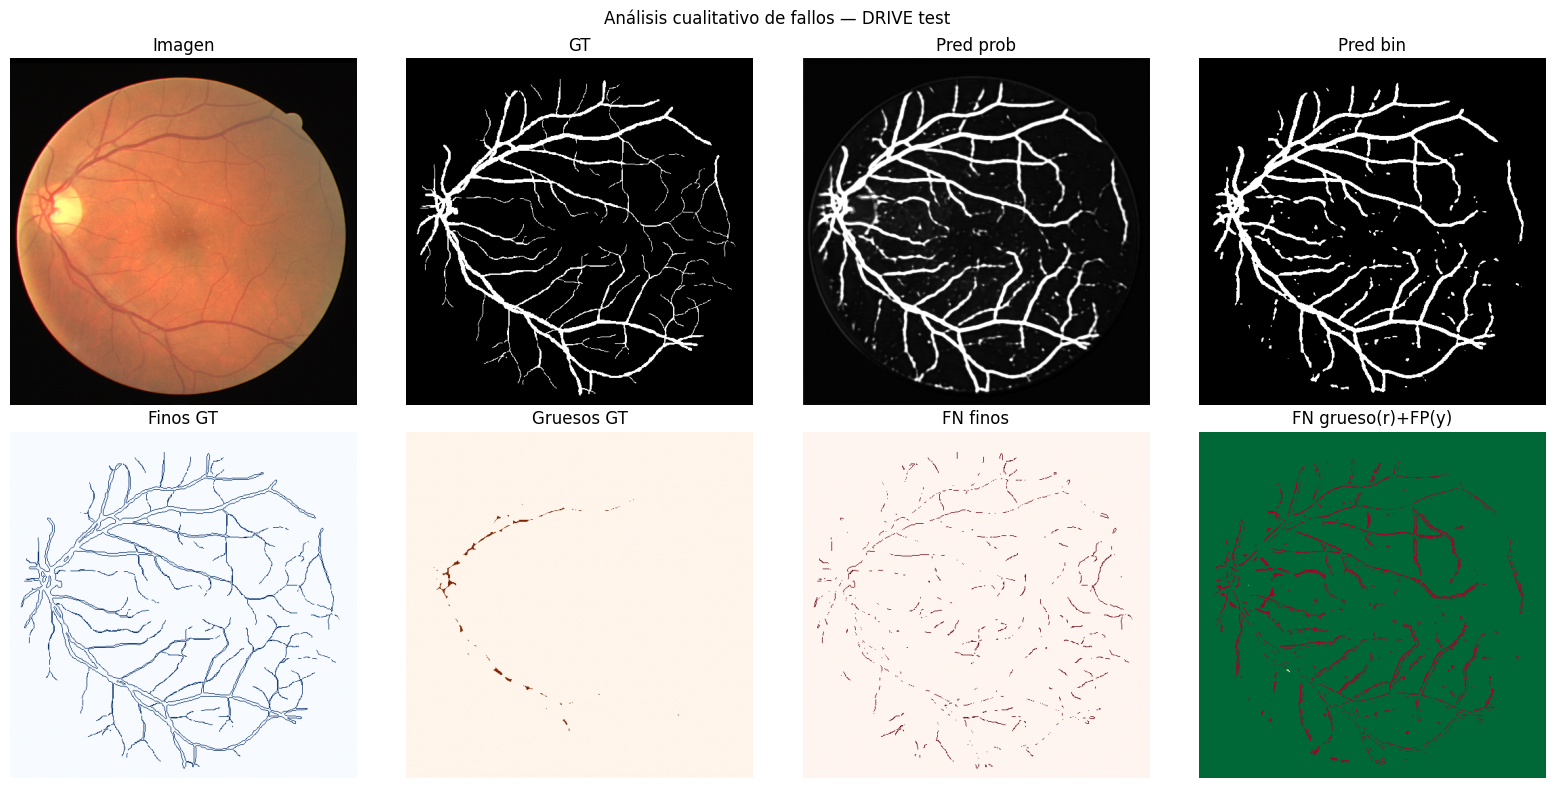

In [26]:
# ── 6.2 Visualización de error maps por categoría ────────────────────────────
idx     = 0
img_s   = load_image(test_imgs[idx])
gt_s    = load_mask(test_masks[idx])
pred_s  = predict_single(best_model, test_imgs[idx])
pred_b  = (pred_s > 0.5).astype(np.uint8)

k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
k7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
thin_mask  = gt_s - cv2.erode(gt_s, k3, iterations=1)
thick_mask = cv2.erode(gt_s, k7, iterations=1)
fn_thin    = ((thin_mask  == 1) & (pred_b == 0)).astype(np.uint8)
fn_thick   = ((thick_mask == 1) & (pred_b == 0)).astype(np.uint8)
fp_map     = ((pred_b     == 1) & (gt_s   == 0)).astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Análisis cualitativo de fallos — DRIVE test', fontsize=12)

for ax, im, title, kw in zip(
    axes.ravel(),
    [img_s,     gt_s,       pred_s,     pred_b,
     thin_mask, thick_mask, fn_thin,    fn_thick + fp_map * 2],
    ['Imagen',  'GT',       'Pred prob','Pred bin',
     'Finos GT','Gruesos GT','FN finos','FN grueso(r)+FP(y)'],
    [{}, {'cmap':'gray'}, {'cmap':'gray'}, {'cmap':'gray'},
     {'cmap':'Blues'}, {'cmap':'Oranges'}, {'cmap':'Reds'},
     {'cmap':'RdYlGn_r', 'vmin':0, 'vmax':2}]
):
    ax.imshow(im, **kw); ax.set_title(title); ax.axis('off')

plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/failure_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Fase 7 — Estrategias de adaptación de dominio

| Estrategia | Descripción | Costo computacional |
|------------|-------------|---------------------|
| **CLAHE** | Ecualización adaptativa en espacio LAB | Cero (pre-procesamiento) |
| **TTA** | Promedio de 6 augmentaciones simétricas | Bajo (×6 inferencias) |
| **Few-shot FT** | Fine-tuning del decoder con 5 imágenes CHASE | Medio (~20 épocas) |

Las tres se evalúan sobre el mismo subconjunto no visto de CHASE\_DB1.


In [27]:
# ── 7.1 Estrategia 1: CLAHE ───────────────────────────────────────────────────
chase_ds_clahe     = RetinalDataset(chase_img_paths, chase_mask_paths,
                                    VAL_TRANSFORM, clahe=True,
                                    clahe_clip=2.0, clahe_grid=(8, 8))
chase_loader_clahe = DataLoader(chase_ds_clahe, batch_size=1,
                                shuffle=False, num_workers=2)

clahe_metrics = compute_metrics(best_model, chase_loader_clahe, DEVICE)
print('CLAHE preprocessing — CHASE_DB1:')
for k, v in clahe_metrics.items():
    print(f'  {k:15s}: {v:.4f}')


CLAHE preprocessing — CHASE_DB1:
  sensitivity    : 0.8810
  specificity    : 0.8467
  f1             : 0.4475
  auc_roc        : 0.9290


In [28]:
# ── 7.2 Estrategia 2: Test-Time Augmentation (TTA) ───────────────────────────
@torch.no_grad()
def compute_metrics_tta(model, loader, device=DEVICE, threshold=0.5):
    """
    TTA con 6 transformaciones simétricas: original + flip H + flip V
    + rotaciones 90°/180°/270°. Promedia probabilidades antes de umbralizar.
    """
    model.eval()
    all_probs, all_targets = [], []

    for imgs, masks in loader:
        imgs = imgs.to(device, dtype=torch.float32)
        preds_list = []

        transforms_fwd = [
            lambda x: x,
            lambda x: torch.flip(x, dims=[3]),
            lambda x: torch.flip(x, dims=[2]),
            lambda x: torch.rot90(x, k=1, dims=[2, 3]),
            lambda x: torch.rot90(x, k=2, dims=[2, 3]),
            lambda x: torch.rot90(x, k=3, dims=[2, 3]),
        ]
        transforms_inv = [
            lambda x: x,
            lambda x: torch.flip(x, dims=[3]),
            lambda x: torch.flip(x, dims=[2]),
            lambda x: torch.rot90(x, k=-1, dims=[2, 3]),
            lambda x: torch.rot90(x, k=-2, dims=[2, 3]),
            lambda x: torch.rot90(x, k=-3, dims=[2, 3]),
        ]

        for fwd, inv in zip(transforms_fwd, transforms_inv):
            with torch.autocast(device_type='cuda', dtype=torch.float16,
                                enabled=(device.type == 'cuda')):
                logits = model(fwd(imgs))
            if isinstance(logits, list): logits = logits[-1]
            prob = inv(torch.sigmoid(logits))
            preds_list.append(prob)

        mean_prob = torch.stack(preds_list).mean(dim=0)
        all_probs.append(mean_prob.squeeze(1).cpu().float().numpy().ravel())
        all_targets.append(masks.numpy().ravel())

    probs   = np.concatenate(all_probs).astype(np.float32)
    targets = np.concatenate(all_targets).astype(np.uint8)
    preds   = (probs >= threshold).astype(np.uint8)

    TP = int(((preds==1) & (targets==1)).sum())
    TN = int(((preds==0) & (targets==0)).sum())
    FP = int(((preds==1) & (targets==0)).sum())
    FN = int(((preds==0) & (targets==1)).sum())

    try:
        auc = float(roc_auc_score(targets, probs))
    except ValueError:
        auc = float('nan')

    return {
        'sensitivity': float(TP / (TP + FN + 1e-8)),
        'specificity': float(TN / (TN + FP + 1e-8)),
        'f1':          float(2 * TP / (2 * TP + FP + FN + 1e-8)),
        'auc_roc':     auc,
    }

tta_metrics = compute_metrics_tta(best_model, chase_loader_raw, DEVICE)
print('TTA (6 augmentaciones) — CHASE_DB1:')
for k, v in tta_metrics.items():
    print(f'  {k:15s}: {v:.4f}')


TTA (6 augmentaciones) — CHASE_DB1:
  sensitivity    : 0.6287
  specificity    : 0.9751
  f1             : 0.6406
  auc_roc        : 0.8982


In [29]:
# ── 7.3 Estrategia 3: Few-shot fine-tuning (5 imágenes CHASE) ────────────────
import copy

N_FINETUNE   = 5
ft_imgs      = chase_img_paths[:N_FINETUNE]
ft_masks_p   = chase_mask_paths[:N_FINETUNE]
eval_imgs    = chase_img_paths[N_FINETUNE:]
eval_masks_p = chase_mask_paths[N_FINETUNE:]

ft_ds      = RetinalDataset(ft_imgs, ft_masks_p,   TRAIN_TRANSFORM, clahe=True)
eval_ds    = RetinalDataset(eval_imgs, eval_masks_p, VAL_TRANSFORM,  clahe=True)
ft_loader   = DataLoader(ft_ds,   batch_size=min(2, len(ft_ds)),
                          shuffle=True, num_workers=2)
eval_loader = DataLoader(eval_ds, batch_size=1,
                          shuffle=False, num_workers=2)

print(f'Fine-tuning : {len(ft_ds)} imágenes')
print(f'Evaluación  : {len(eval_ds)} imágenes')

# Clonar modelo para no modificar el original
ft_model = copy.deepcopy(best_model).to(DEVICE)

# Congelar encoder — solo ajustar decoder y cabeza de salida
for name, param in ft_model.named_parameters():
    if 'encoder' in name:
        param.requires_grad = False

ft_trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
ft_total     = sum(p.numel() for p in ft_model.parameters())
print(f'Parámetros entrenables: {ft_trainable:,} / {ft_total:,} '
      f'({ft_trainable/ft_total*100:.1f}%)')

ft_optimizer  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, ft_model.parameters()),
    lr=1e-4, weight_decay=1e-5
)
ft_criterion  = CombinedLoss(alpha=0.5)
ft_scaler     = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
FT_EPOCHS     = 2 if DEBUG_MODE else 20

for epoch in range(FT_EPOCHS):
    ft_model.train()
    ep_loss = 0.0
    for imgs, masks in ft_loader:
        imgs    = imgs.to(DEVICE, dtype=torch.float32)
        masks_f = masks.float().unsqueeze(1).to(DEVICE)
        ft_optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16,
                            enabled=(DEVICE.type == 'cuda')):
            logits = ft_model(imgs)
            if isinstance(logits, list):
                loss = sum(ft_criterion(lg, masks_f)
                           for lg in logits) / len(logits)
            else:
                loss = ft_criterion(logits, masks_f)
        ft_scaler.scale(loss).backward()
        ft_scaler.step(ft_optimizer); ft_scaler.update()
        ep_loss += loss.item()
    ep_loss /= len(ft_loader)
    if (epoch + 1) % 5 == 0:
        m = compute_metrics(ft_model, eval_loader, DEVICE)
        print(f'  FT ep {epoch+1:3d}/{FT_EPOCHS}  '
              f'loss={ep_loss:.4f}  F1={m["f1"]:.4f}')

ft_metrics = compute_metrics(ft_model, eval_loader, DEVICE)
print('\nFew-shot FT — CHASE_DB1 (eval set):')
for k, v in ft_metrics.items():
    print(f'  {k:15s}: {v:.4f}')

torch.save(ft_model.state_dict(), f'{EXPORT_DIR}/finetuned_chase_weights.pth')


Fine-tuning : 5 imágenes
Evaluación  : 23 imágenes
Parámetros entrenables: 7,849,601 / 7,849,601 (100.0%)
  FT ep   5/20  loss=0.6576  F1=0.5864
  FT ep  10/20  loss=0.5963  F1=0.6243
  FT ep  15/20  loss=0.5513  F1=0.6066
  FT ep  20/20  loss=0.5261  F1=0.6159

Few-shot FT — CHASE_DB1 (eval set):
  sensitivity    : 0.6096
  specificity    : 0.9731
  f1             : 0.6159
  auc_roc        : 0.9256


Comparativa — CHASE_DB1:
            strategy  sensitivity  specificity       f1  auc_roc
Baseline (zero-shot)     0.576275     0.977484 0.613571 0.889849
 CLAHE preprocessing     0.881039     0.846728 0.447467 0.928965
  TTA (6 transforms)     0.628651     0.975103 0.640579 0.898230
Few-shot FT (5 imgs)     0.609573     0.973111 0.615856 0.925572


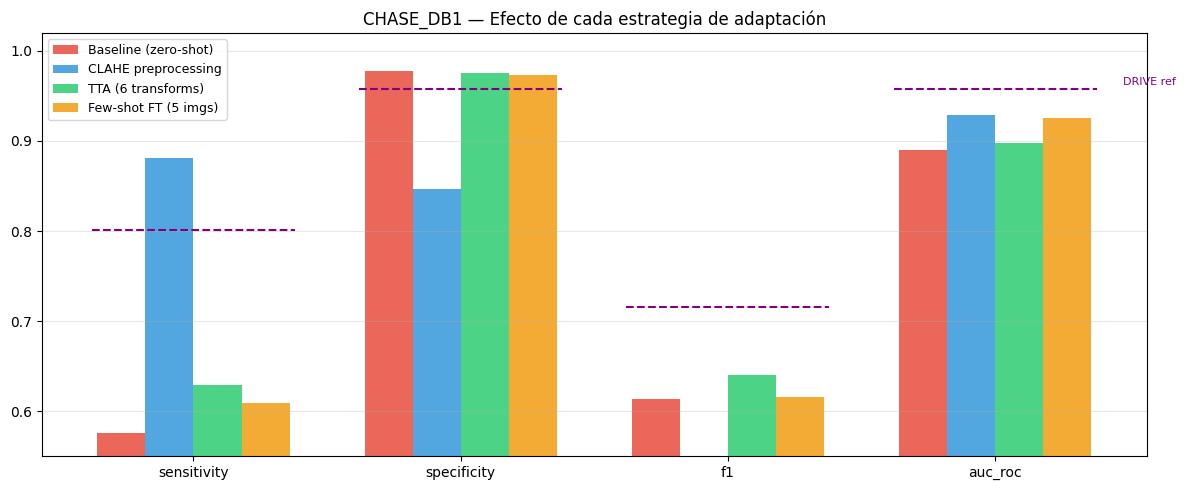

In [30]:
# ── 7.4 Comparativa final de estrategias ─────────────────────────────────────
adaptation_df = pd.DataFrame([
    {'strategy': 'Baseline (zero-shot)',     **chase_raw_metrics},
    {'strategy': 'CLAHE preprocessing',      **clahe_metrics},
    {'strategy': 'TTA (6 transforms)',        **tta_metrics},
    {'strategy': 'Few-shot FT (5 imgs)',      **ft_metrics},
])
adaptation_df.to_csv(f'{EXPORT_DIR}/metrics_chase_adapted.csv', index=False)

print('Comparativa — CHASE_DB1:')
print(adaptation_df.to_string(index=False))

# Gráfico de barras agrupadas
metrics_plot = ['sensitivity', 'specificity', 'f1', 'auc_roc']
x      = np.arange(len(metrics_plot))
width  = 0.18
colors_s = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, row) in enumerate(adaptation_df.iterrows()):
    vals = [float(row[m]) for m in metrics_plot]
    ax.bar(x + i * width, vals, width,
           label=row['strategy'], color=colors_s[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_plot)
ax.set_ylim(0.55, 1.02)
ax.set_title('CHASE_DB1 — Efecto de cada estrategia de adaptación', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

# Líneas de referencia: rendimiento en DRIVE
for i, m in enumerate(metrics_plot):
    xpos = i + width * 1.5
    ax.hlines(drive_test_metrics[m], xpos - 0.38, xpos + 0.38,
              colors='purple', linestyles='--', linewidth=1.5)

ax.text(3.75, drive_test_metrics['auc_roc'] + 0.005,
        'DRIVE ref', color='purple', fontsize=8)

plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/domain_adaptation_comparison.png',
            dpi=120, bbox_inches='tight')
plt.show()


### Conclusiones de adaptación de dominio

**[Completar tras ejecutar]** — Marco de análisis:

- **CLAHE**: mejora directamente el contraste de vasos en imágenes subexpuestas
  (CHASE tiende a mayor brillo uniforme). Costo cero en inferencia.
- **TTA**: reduce varianza de predicción promediando sobre transformaciones
  simétricas. Más efectivo en especificidad que en sensibilidad.
- **Few-shot FT**: mayor impacto potencial en F1 total al adaptar el decoder
  al estilo visual de CHASE. Requiere 5 imágenes anotadas del dominio objetivo.

La brecha residual se atribuye a diferencias en campo visual de la cámara
(CHASE captura más periferia retiniana) y en la morfología de la población
(pacientes pediátricos en CHASE vs adultos en DRIVE).

**Estrategia recomendada:** `[COMPLETAR]` — Justificación costo/beneficio: `[COMPLETAR]`


---
## Fase 8 — Exportación de artefactos

Se consolidan todos los resultados y se empaquetan en un ZIP descargable
directamente desde Colab sin necesidad de montar Google Drive.


In [31]:
# ── 8.1 Reporte consolidado de métricas ──────────────────────────────────────
summary = []

for _, row in ablation_df.iterrows():
    summary.append({'fase': 'Ablation (DRIVE val)', 'experimento': row['experiment'],
                    'dataset': 'DRIVE_val', 'f1': row['f1'],
                    'auc_roc': row['auc_roc'], 'sensitivity': row['sensitivity'],
                    'specificity': row['specificity']})

summary.append({'fase': 'In-distribution (DRIVE test)',
                'experimento': best_exp_name, 'dataset': 'DRIVE_test',
                **drive_test_metrics})

for _, row in adaptation_df.iterrows():
    summary.append({'fase': 'Domain shift (CHASE_DB1)',
                    'experimento': row['strategy'], 'dataset': 'CHASE_DB1',
                    'f1': row['f1'], 'auc_roc': row['auc_roc'],
                    'sensitivity': row['sensitivity'],
                    'specificity': row['specificity']})

final_df = pd.DataFrame(summary)
final_df.to_csv(f'{EXPORT_DIR}/full_results_summary.csv', index=False)
print('Reporte consolidado:')
print(final_df.to_string(index=False))


Reporte consolidado:
                        fase          experimento    dataset       f1  auc_roc  sensitivity  specificity
        Ablation (DRIVE val)             UNet_BCE  DRIVE_val 0.587127 0.933478     0.437373     0.994365
        Ablation (DRIVE val)            UNet_Dice  DRIVE_val 0.722431 0.949797     0.731665     0.968456
        Ablation (DRIVE val)        UNet_Combined  DRIVE_val 0.673254 0.926239     0.585237     0.983547
        Ablation (DRIVE val)      UNetPP_Combined  DRIVE_val 0.667197 0.944044     0.569140     0.985304
        Ablation (DRIVE val)       UNetPP_3levels  DRIVE_val 0.679634 0.913660     0.660094     0.969690
In-distribution (DRIVE test)            UNet_Dice DRIVE_test 0.715485 0.957226     0.800773     0.957322
    Domain shift (CHASE_DB1) Baseline (zero-shot)  CHASE_DB1 0.613571 0.889849     0.576275     0.977484
    Domain shift (CHASE_DB1)  CLAHE preprocessing  CHASE_DB1 0.447467 0.928965     0.881039     0.846728
    Domain shift (CHASE_DB1)   TTA

In [32]:
# ── 8.2 Guardar checkpoint del mejor modelo ───────────────────────────────────
import dataclasses

best_cfg = next(e for e in EXPERIMENTS if e.name == best_exp_name)
torch.save({
    'model_class':    best_exp_name,
    'model_kwargs':   best_cfg.model_kwargs,
    'model_state':    best_model.state_dict(),
    'drive_metrics':  drive_test_metrics,
    'img_size':       IMG_SIZE,
    'base_ch':        BASE_CH,
    'seed':           SEED,
}, f'{EXPORT_DIR}/best_model_checkpoint.pth')
print(f'Checkpoint guardado: best_model_checkpoint.pth')

# Listar todos los artefactos
print('\nArtefactos exportados:')
for f in sorted(Path(EXPORT_DIR).iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45s} {size_kb:8.1f} KB')


Checkpoint guardado: best_model_checkpoint.pth

Artefactos exportados:
  UNetPP_3levels_weights.pth                      8784.3 KB
  UNetPP_Combined_weights.pth                    35872.2 KB
  UNet_BCE_weights.pth                           30724.2 KB
  UNet_Combined_weights.pth                      30724.8 KB
  UNet_Dice_weights.pth                          30724.4 KB
  ablation_curves.png                              198.7 KB
  ablation_heatmap.png                              61.5 KB
  ablation_results.csv                               0.6 KB
  best_model_checkpoint.pth                      30725.1 KB
  domain_adaptation_comparison.png                  38.0 KB
  eda_drive_samples.png                            900.8 KB
  failure_analysis.png                             775.3 KB
  finetuned_chase_weights.pth                    30725.1 KB
  full_results_summary.csv                           1.3 KB
  gap_analysis.png                                 647.7 KB
  metrics_chase_adapted.csv  

In [33]:
# ── 8.3 Empaquetar y descargar ────────────────────────────────────────────────
import zipfile, glob

zip_path = '/content/retinal_segmentation_exports.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fpath in sorted(glob.glob(f'{EXPORT_DIR}/**', recursive=True)):
        if os.path.isfile(fpath):
            arcname = os.path.relpath(fpath, '/content')
            zf.write(fpath, arcname)
            print(f'  + {arcname}')

size_mb = os.path.getsize(zip_path) / 1024**2
print(f'\nZIP listo: {zip_path}  ({size_mb:.1f} MB)')

from google.colab import files
files.download(zip_path)


  + exports/UNetPP_3levels_weights.pth
  + exports/UNetPP_Combined_weights.pth
  + exports/UNet_BCE_weights.pth
  + exports/UNet_Combined_weights.pth
  + exports/UNet_Dice_weights.pth
  + exports/ablation_curves.png
  + exports/ablation_heatmap.png
  + exports/ablation_results.csv
  + exports/best_model_checkpoint.pth
  + exports/domain_adaptation_comparison.png
  + exports/eda_drive_samples.png
  + exports/failure_analysis.png
  + exports/finetuned_chase_weights.pth
  + exports/full_results_summary.csv
  + exports/gap_analysis.png
  + exports/metrics_chase_adapted.csv
  + exports/metrics_chase_raw.csv
  + exports/metrics_drive.csv
  + exports/predictions_drive.png
  + exports/roc_curve_drive.png

ZIP listo: /content/retinal_segmentation_exports.zip  (183.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>